In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [8]:
# Perform analysis on dataset sizes of N = 100.
results = pd.read_csv('../survey/results/results_100.csv', header=None)
print(results.shape)
column_names = ['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Seed', 'Size']
for model in ['rf', 'gbt', 'sv', 'nn', 'gp', 'gp_ard', 'knn']:
    for metric in ['r2', 'mae', 'rmse', 'rel_rmse', 'pearson', 'spearman']:
        column_names.append(f'{model}-{metric}')
results.columns = column_names

(59998, 49)


In [9]:
# Filter out tasks which are too difficult by rho < 0.1.
METRIC = 'spearman'
included_columns = [name for name in column_names if METRIC in name]
included_columns.insert(0, 'Seed')
included_columns.insert(0, 'Batch')
included_columns.insert(0, 'Model')
included_columns.insert(0, 'Sampler')
included_columns.insert(0, 'Strategy')
included_columns.insert(0, 'Task')
task_results = results[included_columns]

task_results_long = task_results.melt(
    id_vars=['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Seed'],
    value_vars=[name for name in column_names if METRIC in name],
    var_name='metric_full',
    value_name='metric_value'
)
task_results_long['Predictor'] = task_results_long['metric_full'].str.replace(f'-{METRIC}$', '', regex=True)
task_results_long.head(10)

task_performances = task_results_long.loc[:,['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Seed', 'Predictor', 'metric_value']]
task_performances = task_performances.groupby(by='Task')['metric_value'].agg(['mean']).reset_index()
task_performances = task_performances.sort_values(by='mean', ascending=False)

task_performances = task_performances[(task_performances['mean'] > 0.1)]
task_performances.head(50)
intermediate_tasks = task_performances['Task'].to_list()

print(f'Number of intermediate tasks: {len(intermediate_tasks)}')

Number of intermediate tasks: 46


In [10]:
# Determine top-performing dataset selection strategies, averaged across
# all tasks and proprety prediction architectures.
METRIC = 'spearman'
included_columns = [name for name in column_names if METRIC in name]
included_columns.insert(0, 'Seed')
included_columns.insert(0, 'Batch')
included_columns.insert(0, 'Model')
included_columns.insert(0, 'Sampler')
included_columns.insert(0, 'Strategy')
included_columns.insert(0, 'Task')
average_results = results[included_columns]
average_results.head(20)

average_results_long = average_results.melt(
    id_vars=['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Seed'],
    value_vars=[name for name in column_names if METRIC in name],
    var_name='metric_full',
    value_name='metric_value'
)
average_results_long['Predictor'] = average_results_long['metric_full'].str.replace(f'-{METRIC}$', '', regex=True)
average_results_long.head(10)

average_results_long = average_results_long[average_results_long['Task'].isin(intermediate_tasks)]

norm_factors = average_results_long.groupby(['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Predictor'])['metric_value'].mean().reset_index()
if METRIC in ['r2', 'spearman', 'pearson']:
    norm_factors = norm_factors.groupby('Task')['metric_value'].max().reset_index()
else:
    norm_factors = norm_factors.groupby('Task')['metric_value'].min().reset_index()
norm_factors = norm_factors.set_index('Task')['metric_value'].to_dict()
average_results_long['score_norm'] = average_results_long['metric_value'] / average_results_long['Task'].map(norm_factors)

average_results_long = average_results_long[['Strategy', 'Sampler', 'Model', 'Batch', 'Predictor', 'score_norm']]
average_results_grouped = average_results_long.groupby(['Strategy', 'Sampler', 'Model', 'Batch'])
average_results_agg = average_results_grouped['score_norm'].agg(['mean', 'sem']).reset_index()
if METRIC in ['pearson', 'spearman']:
    average_results_agg = average_results_agg.sort_values(by='mean', ascending=False)
if METRIC in ['mae', 'rel_rmse']:
    average_results_agg = average_results_agg.sort_values(by='mean', ascending=True)

average_results_agg.head(20)

,Strategy,Sampler,Model,Batch,mean,sem
98,sf,medoids,none,none,0.903405,0.002719
60,al,medoids,nn,cluster_margin,0.892829,0.002849
12,al,max_entropy,nn,cluster_margin,0.889101,0.002913
84,al,random,nn,cluster_margin,0.886945,0.002971
36,al,maximin,nn,cluster_margin,0.884871,0.002992
4,al,max_entropy,gp_ard,cluster_margin,0.882715,0.003030
0,al,max_entropy,gp,cluster_margin,0.882695,0.003033
48,al,medoids,gp,cluster_margin,0.882214,0.003011
52,al,medoids,gp_ard,cluster_margin,0.881065,0.003005
76,al,random,gp_ard,cluster_margin,0.878856,0.002919


13


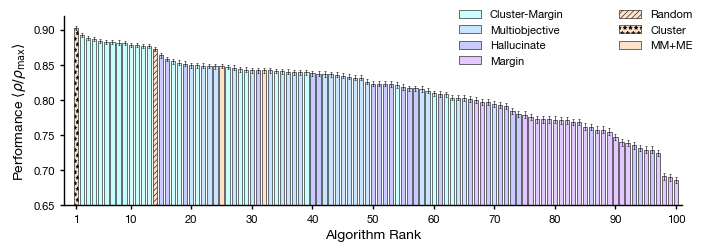

In [11]:
# Generate figure showing the relative performance of training set selection strategies.
al_counter = 0
plot_data = []
for _, row in average_results_agg.iterrows():
    if 'sf' in row['Strategy']:
        plot_data.append((f'{row["Sampler"]}', row['mean'], row['sem']))
    else:
        al_counter += 1
        plot_data.append((f'{row["Sampler"]}-{row["Model"]}-{row["Batch"]}', row['mean'], row['sem']))

# Generate figure.
plt.rcParams['font.family'] = 'Helvetica Neue'
plt.rcParams['font.size'] = 8
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['hatch.linewidth'] = 0.4

# Revised color palette.
def get_color(label):

    # Active learning.
    if len(label.split('-')) > 1:
        
        if 'cluster_margin' in label:
            return "#C9FFFE"
        
        elif 'pareto' in label:
            return "#C9E5FF"

        elif 'hallucinate' in label:
            return "#C9CAFF"
        
        elif 'topk' in label:
            return "#E3C9FF"
    
    # Random.
    elif 'random' in label:
        return "#FFE3C9"
    
    elif 'medoids' in label:
        return "#FFE3C9"
    
    # Space-filling.
    else:
        return "#FFE3C9"

fig, ax = plt.subplots(1,1,figsize=(7.0,2.5))

x_locations = [i + 1 for i in range(len(plot_data))]
levels = [datum[1] for datum in plot_data]
colors = [get_color(datum[0]) for datum in plot_data]
random_idx = -1
for idx, datum in enumerate(plot_data):
    if 'random' == datum[0]:
        random_idx = idx
print(random_idx)
errors = [datum[2] for datum in plot_data]
bars = ax.bar(x_locations, levels, yerr=errors, color=colors, width=0.7, linewidth=0.4, edgecolor='black', error_kw={'linewidth': 0.4, 'capsize': 0.6, 'capthick': 0.4})
bars[random_idx].set_hatch('//////')
bars[0].set_hatch('***')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#C9FFFE', label='Cluster-Margin', edgecolor='black', linewidth=0.4),
    Patch(facecolor='#C9E5FF', label='Multiobjective', edgecolor='black', linewidth=0.4),
    Patch(facecolor='#C9CAFF', label='Hallucinate', edgecolor='black', linewidth=0.4),
    Patch(facecolor='#E3C9FF', label='Margin', edgecolor='black', linewidth=0.4),
    Patch(facecolor='#FFE3C9', hatch='//////', label='Random', edgecolor='black', linewidth=0.4),
    Patch(facecolor='#FFE3C9', hatch='***', label='Cluster', edgecolor='black', linewidth=0.4),
    Patch(facecolor='#FFE3C9', label='MM+ME', edgecolor='black', linewidth=0.4)
]

ax.set_xlabel('Algorithm Rank', fontsize=10)
ax.tick_params(axis='both', left=True, bottom=True, width=1.0, length=3.0)
ax.set_xlim(xmin=-1.0, xmax=len(plot_data) + 1.0)
ax.set_xticks([1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
ax.set_ylim(ymin=0.65, ymax=0.92)
ax.set_ylabel(r'Performance $\langle\rho / \rho_{\text{max}}\rangle$', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
fig.legend(handles=legend_elements, edgecolor='white', ncol=2, columnspacing=5.0)

plt.tight_layout()
plt.savefig('figures/survey.png', dpi=500, transparent=False)
plt.show()

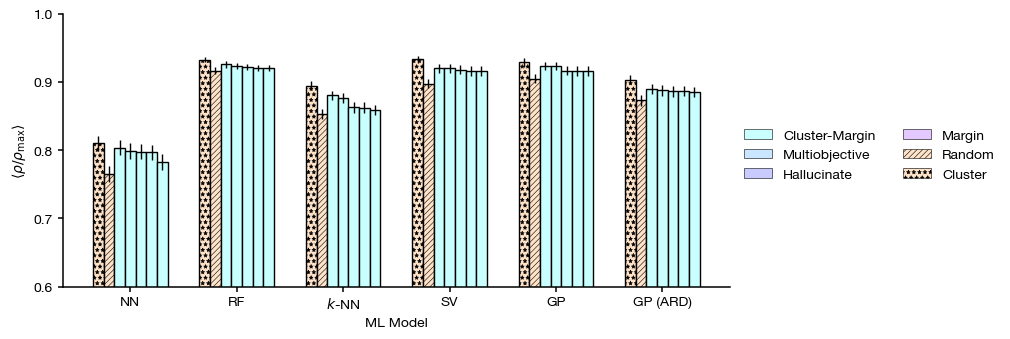

In [12]:
# Get model-by-model breakdown in performances.
METRIC = 'spearman'
included_columns = [name for name in column_names if METRIC in name]
included_columns.insert(0, 'Seed')
included_columns.insert(0, 'Batch')
included_columns.insert(0, 'Model')
included_columns.insert(0, 'Sampler')
included_columns.insert(0, 'Strategy')
included_columns.insert(0, 'Task')
average_results = results[included_columns]
average_results_long = average_results.melt(
    id_vars=['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Seed'],
    value_vars=[name for name in column_names if METRIC in name],
    var_name='metric_full',
    value_name='metric_value'
)
average_results_long['Predictor'] = average_results_long['metric_full'].str.replace(f'-{METRIC}$', '', regex=True)
average_results_long = average_results_long[average_results_long['Task'].isin(intermediate_tasks)]
norm_factors = average_results_long.groupby(['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Predictor'])['metric_value'].mean().reset_index()
if METRIC in ['r2', 'spearman', 'pearson']:
    norm_factors = norm_factors.groupby('Task')['metric_value'].max().reset_index()
else:
    norm_factors = norm_factors.groupby('Task')['metric_value'].min().reset_index()
norm_factors = norm_factors.set_index('Task')['metric_value'].to_dict()
average_results_long['score_norm'] = average_results_long['metric_value'] / average_results_long['Task'].map(norm_factors)
average_results_long = average_results_long[['Strategy', 'Sampler', 'Model', 'Batch', 'Predictor', 'score_norm']]

# Prepare figure on a model-by-model basis.
plt.rcParams['font.family'] = 'Helvetica Neue'
plt.rcParams['font.size'] = 10
plt.rcParams['axes.linewidth'] = 1.1
fig, ax = plt.subplots(1,1,figsize=(7.5,3.5))
predictors = ['nn', 'rf', 'knn', 'sv', 'gp', 'gp_ard']
predictor_labels = ['NN', 'RF', '$\it{k}$'+ '-NN', 'SV', 'GP', 'GP (ARD)']
for p_idx, p in enumerate(predictors):

    # Gather model-specific data.
    temp_dataset = average_results_long[average_results_long['Predictor'] == p]
    temp_dataset = temp_dataset[['Strategy', 'Sampler', 'Model', 'Batch', 'Predictor', 'score_norm']]
    temp_dataset = temp_dataset.groupby(['Strategy', 'Sampler', 'Model', 'Batch'])
    temp_dataset = temp_dataset['score_norm'].agg(['mean', 'sem']).reset_index()
    if METRIC in ['pearson', 'spearman']:
        temp_dataset = temp_dataset.sort_values(by='mean', ascending=False)
    if METRIC in ['mae', 'rel_rmse']:
        temp_dataset = temp_dataset.sort_values(by='mean', ascending=True)

    # Get appropriate data for plotting.
    y = [0, 0, 0, 0, 0, 0, 0]
    y_err = [0, 0, 0, 0, 0, 0, 0]
    al_counter = 0
    colors = ["#FFE3C9", "#FFE3C9", '', '', '', '', '']
    batch_color = {
        'cluster_margin': "#C9FFFE",
        'pareto': "#C9E5FF",
        'hallucinate': "#C9CAFF",
        'topk': "#E3C9FF"
    }
    for iter, row in temp_dataset.iterrows():
        if row['Strategy'] == 'sf' and row['Sampler'] == 'medoids':
            y[0] = row['mean']
            y_err[0] = row['sem']
        elif row['Strategy'] == 'sf' and row['Sampler'] == 'random':
            y[1] = row['mean']
            y_err[1] = row['sem']
        if row['Strategy'] == 'al' and al_counter < 5:
            y[2 + al_counter] = row['mean']
            y_err[2 + al_counter] = row['sem']
            colors[2 + al_counter] = batch_color[row['Batch']]
            al_counter += 1

    # Plot data in appropriate location.
    x_center = p_idx + 1
    width = 0.10
    n_algos_per_predictor = 7
    x_values = [(width * (i + 0.5)) - (width * n_algos_per_predictor / 2) + x_center for i in range(n_algos_per_predictor)]
    bars = ax.bar(
        x=x_values, 
        height=y,
        yerr=y_err,
        width=width,
        color=colors,
        edgecolor='black',
        linewidth=1.0,
        error_kw={'linewidth': 1.0}
    )
    bars[0].set_hatch('***')
    bars[1].set_hatch('//////')

ax.set_xlabel('ML Model')
ax.set_ylabel(r'$\langle \rho / \rho_{\text{max}} \rangle$')
ax.set_ylim(ymin=0.6, ymax=1.0)
ax.set_xticks(ticks=[i+1 for i in range(len(predictors))], labels=predictor_labels)
ax.set_yticks(ticks=[0.6, 0.7, 0.8, 0.9, 1.0])
ax.tick_params(width=1.1, length=3.6)
ax.spines[['top', 'right']].set_visible(False)

# Add legend.
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#C9FFFE', label='Cluster-Margin', edgecolor='black', linewidth=0.4),
    Patch(facecolor='#C9E5FF', label='Multiobjective', edgecolor='black', linewidth=0.4),
    Patch(facecolor='#C9CAFF', label='Hallucinate', edgecolor='black', linewidth=0.4),
    Patch(facecolor='#E3C9FF', label='Margin', edgecolor='black', linewidth=0.4),
    # Patch(facecolor='#FFE3C9', label='Space-Filling', edgecolor='black', linewidth=0.4),
    Patch(facecolor='#FFE3C9', hatch='//////', label='Random', edgecolor='black', linewidth=0.4),
    Patch(facecolor='#FFE3C9', hatch='***', label='Cluster', edgecolor='black', linewidth=0.4),
]
fig.legend(handles=legend_elements, edgecolor='white', ncol=2, bbox_to_anchor=(1.35, 0.65))

plt.tight_layout()
plt.savefig('./figures/results_by_model.pdf', dpi=500, bbox_inches='tight')
plt.show()

In [14]:
# Perform analysis on dataset sizes of N = 50.
results = pd.read_csv('../survey/results/results_50.csv', header=None)
column_names = ['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Seed', 'Size']
for model in ['rf', 'gbt', 'sv', 'nn', 'gp', 'gp_ard', 'knn']:
    for metric in ['r2', 'mae', 'rmse', 'rel_rmse', 'pearson', 'spearman']:
        column_names.append(f'{model}-{metric}')
results.columns = column_names

# Filter out tasks which are too difficult by rho < 0.1.
METRIC = 'spearman'
included_columns = [name for name in column_names if METRIC in name]
included_columns.insert(0, 'Seed')
included_columns.insert(0, 'Batch')
included_columns.insert(0, 'Model')
included_columns.insert(0, 'Sampler')
included_columns.insert(0, 'Strategy')
included_columns.insert(0, 'Task')
task_results = results[included_columns]

task_results_long = task_results.melt(
    id_vars=['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Seed'],
    value_vars=[name for name in column_names if METRIC in name],
    var_name='metric_full',
    value_name='metric_value'
)
task_results_long['Predictor'] = task_results_long['metric_full'].str.replace(f'-{METRIC}$', '', regex=True)
task_results_long.head(10)

task_performances = task_results_long.loc[:,['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Seed', 'Predictor', 'metric_value']]
task_performances = task_performances.groupby(by='Task')['metric_value'].agg(['mean']).reset_index()
task_performances = task_performances.sort_values(by='mean', ascending=False)

task_performances = task_performances[(task_performances['mean'] > 0.1)]
task_performances.head(50)
intermediate_tasks = task_performances['Task'].to_list()

print(f'Number of intermediate tasks: {len(intermediate_tasks)}')

# Determine top-performing dataset selection strategies, averaged across
# all tasks and proprety prediction architectures.
METRIC = 'spearman'
included_columns = [name for name in column_names if METRIC in name]
included_columns.insert(0, 'Seed')
included_columns.insert(0, 'Batch')
included_columns.insert(0, 'Model')
included_columns.insert(0, 'Sampler')
included_columns.insert(0, 'Strategy')
included_columns.insert(0, 'Task')
average_results = results[included_columns]
average_results.head(20)

average_results_long = average_results.melt(
    id_vars=['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Seed'],
    value_vars=[name for name in column_names if METRIC in name],
    var_name='metric_full',
    value_name='metric_value'
)
average_results_long['Predictor'] = average_results_long['metric_full'].str.replace(f'-{METRIC}$', '', regex=True)
average_results_long.head(10)

average_results_long = average_results_long[average_results_long['Task'].isin(intermediate_tasks)]

norm_factors = average_results_long.groupby(['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Predictor'])['metric_value'].mean().reset_index()
if METRIC in ['r2', 'spearman', 'pearson']:
    norm_factors = norm_factors.groupby('Task')['metric_value'].max().reset_index()
else:
    norm_factors = norm_factors.groupby('Task')['metric_value'].min().reset_index()
norm_factors = norm_factors.set_index('Task')['metric_value'].to_dict()
average_results_long['score_norm'] = average_results_long['metric_value'] / average_results_long['Task'].map(norm_factors)

average_results_long = average_results_long[['Strategy', 'Sampler', 'Model', 'Batch', 'Predictor', 'score_norm']]
average_results_grouped = average_results_long.groupby(['Strategy', 'Sampler', 'Model', 'Batch'])
average_results_agg = average_results_grouped['score_norm'].agg(['mean', 'sem']).reset_index()
if METRIC in ['pearson', 'spearman']:
    average_results_agg = average_results_agg.sort_values(by='mean', ascending=False)
if METRIC in ['mae', 'rel_rmse']:
    average_results_agg = average_results_agg.sort_values(by='mean', ascending=True)

average_results_agg.head(20)

Number of intermediate tasks: 44


,Strategy,Sampler,Model,Batch,mean,sem
98,sf,medoids,none,none,0.891019,0.002971
52,al,medoids,gp_ard,cluster_margin,0.875009,0.003181
48,al,medoids,gp,cluster_margin,0.869484,0.003334
12,al,max_entropy,nn,cluster_margin,0.866332,0.003348
0,al,max_entropy,gp,cluster_margin,0.863110,0.003419
4,al,max_entropy,gp_ard,cluster_margin,0.862602,0.003420
60,al,medoids,nn,cluster_margin,0.859534,0.003549
24,al,maximin,gp,cluster_margin,0.856317,0.003465
28,al,maximin,gp_ard,cluster_margin,0.856278,0.003470
84,al,random,nn,cluster_margin,0.854293,0.003737


13


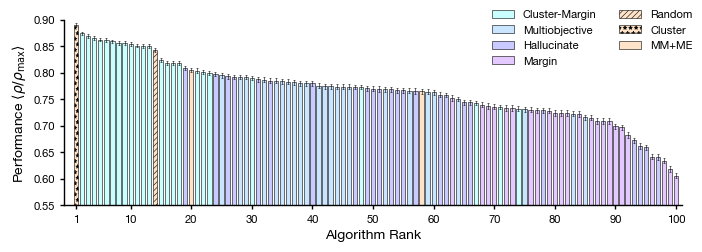

In [15]:
# Generate figure showing the relative performance of training set selection strategies.
al_counter = 0
plot_data = []
for _, row in average_results_agg.iterrows():
    if 'sf' in row['Strategy']:
        plot_data.append((f'{row["Sampler"]}', row['mean'], row['sem']))
    else:
        al_counter += 1
        plot_data.append((f'{row["Sampler"]}-{row["Model"]}-{row["Batch"]}', row['mean'], row['sem']))

# Generate figure.
plt.rcParams['font.family'] = 'Helvetica Neue'
plt.rcParams['font.size'] = 8
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['hatch.linewidth'] = 0.4

# Revised color palette.
def get_color(label):

    # Active learning.
    if len(label.split('-')) > 1:
        
        if 'cluster_margin' in label:
            return "#C9FFFE"
        
        elif 'pareto' in label:
            return "#C9E5FF"

        elif 'hallucinate' in label:
            return "#C9CAFF"
        
        elif 'topk' in label:
            return "#E3C9FF"
    
    # Random.
    elif 'random' in label:
        return "#FFE3C9"
    
    elif 'medoids' in label:
        return "#FFE3C9"
    
    # Space-filling.
    else:
        return "#FFE3C9"

fig, ax = plt.subplots(1,1,figsize=(7.0,2.5))

x_locations = [i + 1 for i in range(len(plot_data))]
levels = [datum[1] for datum in plot_data]
colors = [get_color(datum[0]) for datum in plot_data]
random_idx = -1
for idx, datum in enumerate(plot_data):
    if 'random' == datum[0]:
        random_idx = idx
print(random_idx)
errors = [datum[2] for datum in plot_data]
bars = ax.bar(x_locations, levels, yerr=errors, color=colors, width=0.7, linewidth=0.4, edgecolor='black', error_kw={'linewidth': 0.4, 'capsize': 0.6, 'capthick': 0.4})
bars[random_idx].set_hatch('//////')
bars[0].set_hatch('***')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#C9FFFE', label='Cluster-Margin', edgecolor='black', linewidth=0.4),
    Patch(facecolor='#C9E5FF', label='Multiobjective', edgecolor='black', linewidth=0.4),
    Patch(facecolor='#C9CAFF', label='Hallucinate', edgecolor='black', linewidth=0.4),
    Patch(facecolor='#E3C9FF', label='Margin', edgecolor='black', linewidth=0.4),
    Patch(facecolor='#FFE3C9', hatch='//////', label='Random', edgecolor='black', linewidth=0.4),
    Patch(facecolor='#FFE3C9', hatch='***', label='Cluster', edgecolor='black', linewidth=0.4),
    Patch(facecolor='#FFE3C9', label='MM+ME', edgecolor='black', linewidth=0.4),
]

ax.set_xlabel('Algorithm Rank', fontsize=10)
ax.tick_params(axis='both', left=True, bottom=True, width=1.0, length=3.0)
ax.set_xlim(xmin=-1.0, xmax=len(plot_data) + 1.0)
ax.set_xticks([1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
ax.set_ylim(ymin=0.55, ymax=0.90)
ax.set_ylabel(r'Performance $\langle\rho / \rho_{\text{max}}\rangle$', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
fig.legend(handles=legend_elements, edgecolor='white', ncol=2)

plt.tight_layout()
plt.savefig('figures/survey_50.pdf', dpi=500, transparent=True)
plt.show()

In [16]:
# Perform analysis on dataset sizes of N = 200.
results = pd.read_csv('../survey/results/results_200.csv', header=None)
column_names = ['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Seed', 'Size']
for model in ['rf', 'gbt', 'sv', 'nn', 'gp', 'gp_ard', 'knn']:
    for metric in ['r2', 'mae', 'rmse', 'rel_rmse', 'pearson', 'spearman']:
        column_names.append(f'{model}-{metric}')
results.columns = column_names

# Filter out tasks which are too difficult by rho < 0.1.
METRIC = 'spearman'
included_columns = [name for name in column_names if METRIC in name]
included_columns.insert(0, 'Seed')
included_columns.insert(0, 'Batch')
included_columns.insert(0, 'Model')
included_columns.insert(0, 'Sampler')
included_columns.insert(0, 'Strategy')
included_columns.insert(0, 'Task')
task_results = results[included_columns]

task_results_long = task_results.melt(
    id_vars=['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Seed'],
    value_vars=[name for name in column_names if METRIC in name],
    var_name='metric_full',
    value_name='metric_value'
)
task_results_long['Predictor'] = task_results_long['metric_full'].str.replace(f'-{METRIC}$', '', regex=True)
task_results_long.head(10)

task_performances = task_results_long.loc[:,['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Seed', 'Predictor', 'metric_value']]
task_performances = task_performances.groupby(by='Task')['metric_value'].agg(['mean']).reset_index()
task_performances = task_performances.sort_values(by='mean', ascending=False)

task_performances = task_performances[(task_performances['mean'] > 0.1)]
task_performances.head(50)
intermediate_tasks = task_performances['Task'].to_list()

print(f'Number of intermediate tasks: {len(intermediate_tasks)}')

# Determine top-performing dataset selection strategies, averaged across
# all tasks and proprety prediction architectures.
METRIC = 'spearman'
included_columns = [name for name in column_names if METRIC in name]
included_columns.insert(0, 'Seed')
included_columns.insert(0, 'Batch')
included_columns.insert(0, 'Model')
included_columns.insert(0, 'Sampler')
included_columns.insert(0, 'Strategy')
included_columns.insert(0, 'Task')
average_results = results[included_columns]
average_results.head(20)

average_results_long = average_results.melt(
    id_vars=['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Seed'],
    value_vars=[name for name in column_names if METRIC in name],
    var_name='metric_full',
    value_name='metric_value'
)
average_results_long['Predictor'] = average_results_long['metric_full'].str.replace(f'-{METRIC}$', '', regex=True)
average_results_long.head(10)

average_results_long = average_results_long[average_results_long['Task'].isin(intermediate_tasks)]

norm_factors = average_results_long.groupby(['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Predictor'])['metric_value'].mean().reset_index()
if METRIC in ['r2', 'spearman', 'pearson']:
    norm_factors = norm_factors.groupby('Task')['metric_value'].max().reset_index()
else:
    norm_factors = norm_factors.groupby('Task')['metric_value'].min().reset_index()
norm_factors = norm_factors.set_index('Task')['metric_value'].to_dict()
average_results_long['score_norm'] = average_results_long['metric_value'] / average_results_long['Task'].map(norm_factors)

average_results_long = average_results_long[['Strategy', 'Sampler', 'Model', 'Batch', 'Predictor', 'score_norm']]
average_results_grouped = average_results_long.groupby(['Strategy', 'Sampler', 'Model', 'Batch'])
average_results_agg = average_results_grouped['score_norm'].agg(['mean', 'sem']).reset_index()
if METRIC in ['pearson', 'spearman']:
    average_results_agg = average_results_agg.sort_values(by='mean', ascending=False)
if METRIC in ['mae', 'rel_rmse']:
    average_results_agg = average_results_agg.sort_values(by='mean', ascending=True)

average_results_agg.head(20)

Number of intermediate tasks: 49


,Strategy,Sampler,Model,Batch,mean,sem
98,sf,medoids,none,none,0.907062,0.002635
60,al,medoids,nn,cluster_margin,0.904342,0.002559
12,al,max_entropy,nn,cluster_margin,0.903615,0.002541
84,al,random,nn,cluster_margin,0.898758,0.002691
36,al,maximin,nn,cluster_margin,0.897863,0.002728
52,al,medoids,gp_ard,cluster_margin,0.892491,0.002634
48,al,medoids,gp,cluster_margin,0.891247,0.002721
61,al,medoids,nn,hallucinate,0.887016,0.002671
28,al,maximin,gp_ard,cluster_margin,0.885578,0.002804
24,al,maximin,gp,cluster_margin,0.885489,0.002812


15


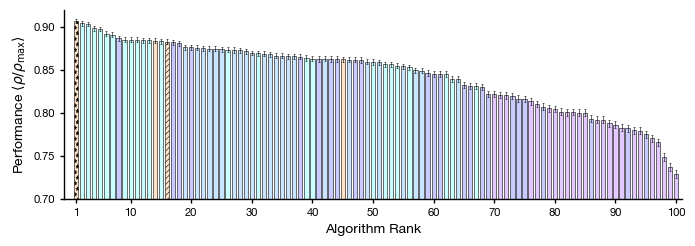

In [ ]:
# Generate figure showing the relative performance of training set selection strategies.
al_counter = 0
plot_data = []
for _, row in average_results_agg.iterrows():
    if 'sf' in row['Strategy']:
        plot_data.append((f'{row["Sampler"]}', row['mean'], row['sem']))
    else:
        al_counter += 1
        plot_data.append((f'{row["Sampler"]}-{row["Model"]}-{row["Batch"]}', row['mean'], row['sem']))

# Generate figure.
plt.rcParams['font.family'] = 'Helvetica Neue'
plt.rcParams['font.size'] = 8
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams['hatch.linewidth'] = 0.4

# Revised color palette.
def get_color(label):

    # Active learning.
    if len(label.split('-')) > 1:
        
        if 'cluster_margin' in label:
            return "#C9FFFE"
        
        elif 'pareto' in label:
            return "#C9E5FF"

        elif 'hallucinate' in label:
            return "#C9CAFF"
        
        elif 'topk' in label:
            return "#E3C9FF"
    
    # Random.
    elif 'random' in label:
        return "#FFE3C9"
    
    elif 'medoids' in label:
        return "#FFE3C9"
    
    # Space-filling.
    else:
        return "#FFE3C9"

fig, ax = plt.subplots(1,1,figsize=(7.0,2.5))

x_locations = [i + 1 for i in range(len(plot_data))]
levels = [datum[1] for datum in plot_data]
colors = [get_color(datum[0]) for datum in plot_data]
random_idx = -1
for idx, datum in enumerate(plot_data):
    if 'random' == datum[0]:
        random_idx = idx
print(random_idx)
errors = [datum[2] for datum in plot_data]
bars = ax.bar(x_locations, levels, yerr=errors, color=colors, width=0.7, linewidth=0.4, edgecolor='black', error_kw={'linewidth': 0.4, 'capsize': 0.6, 'capthick': 0.4})
bars[random_idx].set_hatch('//////')
bars[0].set_hatch('***')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#C9FFFE', label='Cluster-Margin', edgecolor='black', linewidth=0.4),
    Patch(facecolor='#C9E5FF', label='Multiobjective', edgecolor='black', linewidth=0.4),
    Patch(facecolor='#C9CAFF', label='Hallucinate', edgecolor='black', linewidth=0.4),
    Patch(facecolor='#E3C9FF', label='Margin', edgecolor='black', linewidth=0.4),
    Patch(facecolor='#FFE3C9', hatch='//////', label='Random', edgecolor='black', linewidth=0.4),
    Patch(facecolor='#FFE3C9', hatch='***', label='Cluster', edgecolor='black', linewidth=0.4),
    Patch(facecolor='#FFE3C9', label='MM+ME', edgecolor='black', linewidth=0.4),
]

ax.set_xlabel('Algorithm Rank', fontsize=10)
ax.tick_params(axis='both', left=True, bottom=True, width=1.0, length=3.0)
ax.set_xlim(xmin=-1.0, xmax=len(plot_data) + 1.0)
ax.set_xticks([1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
ax.set_ylim(ymin=0.70, ymax=0.92)
ax.set_ylabel(r'Performance $\langle\rho / \rho_{\text{max}}\rangle$', fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
# fig.legend(handles=legend_elements, edgecolor='white', ncol=2)

plt.tight_layout()
plt.savefig('figures/survey_200.pdf', dpi=500, transparent=True)
plt.show()

In [ ]:
# Determine top-performing dataset selection strategies, averaged across
# all tasks and proprety prediction architectures.
METRIC = 'spearman'
included_columns = [name for name in column_names if METRIC in name]
included_columns.insert(0, 'Seed')
included_columns.insert(0, 'Batch')
included_columns.insert(0, 'Model')
included_columns.insert(0, 'Sampler')
included_columns.insert(0, 'Strategy')
included_columns.insert(0, 'Task')
average_results = results[included_columns]
average_results.head(20)

average_results_long = average_results.melt(
    id_vars=['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Seed'],
    value_vars=[name for name in column_names if METRIC in name],
    var_name='metric_full',
    value_name='metric_value'
)
average_results_long['Predictor'] = average_results_long['metric_full'].str.replace(f'-{METRIC}$', '', regex=True)
average_results_long.head(10)

average_results_long = average_results_long[average_results_long['Task'].isin(intermediate_tasks)]

norm_factors = average_results_long.groupby(['Task', 'Strategy', 'Sampler', 'Model', 'Batch', 'Predictor'])['metric_value'].mean().reset_index()
if METRIC in ['r2', 'spearman', 'pearson']:
    norm_factors = norm_factors.groupby('Task')['metric_value'].max().reset_index()
else:
    norm_factors = norm_factors.groupby('Task')['metric_value'].min().reset_index()
norm_factors = norm_factors.set_index('Task')['metric_value'].to_dict()
average_results_long['score_norm'] = average_results_long['metric_value'] / average_results_long['Task'].map(norm_factors)

average_results_long = average_results_long[['Strategy', 'Sampler', 'Model', 'Batch', 'Predictor', 'score_norm']]
average_results_grouped = average_results_long.groupby(['Batch'])
average_results_agg = average_results_grouped['score_norm'].agg(['mean', 'sem']).reset_index()
if METRIC in ['pearson', 'spearman']:
    average_results_agg = average_results_agg.sort_values(by='mean', ascending=False)
if METRIC in ['mae', 'rel_rmse']:
    average_results_agg = average_results_agg.sort_values(by='mean', ascending=True)

average_results_agg.head(20)

,Batch,mean,sem
2,none,0.884395,0.001392
0,cluster_margin,0.873727,0.000611
3,pareto,0.866018,0.000611
1,hallucinate,0.840755,0.000705
4,topk,0.790221,0.000825
